# LINK to Github Repo: (https://github.com/RyanWri/afeka-nlp-homeworks)
## repo is private, request access if needed

------------------------------------------------------------------------------------------
# Section 1

## sentences located at homework_2/data folder 
- Load sentences from the file: **`data/sentences.txt`**.
- Use **NLTK's word tokenizer** to process the text behind the scenes.


In [1]:
from word_2_vec import read_sentences

file_path = "data/sentences.txt"
sentences = read_sentences(file_path)

---------------------------------------------------------------------------------------------
# 1A Write Python program to implement Skip-gram Word2Vec algorithm.

In [2]:
from gensim.models import Word2Vec

skip_gram_model = Word2Vec(
    sentences=sentences,
    vector_size=50,  # Embedding dimensions
    window=2,  # Context window size
    min_count=1,  # Include all words
    sg=1,  # Skip-gram algorithm
    epochs=50,  # Number of training epochs
    negative=5,  # Negative sampling
    sample=1e-3,  # Subsampling frequent words
    alpha=0.01,  # Learning rate
)

---------------------------------------------------------------------------------------------
# 1B Write Python program to implement CBOW Word2Vec algorithm.

In [3]:
cbow_model = Word2Vec(
    sentences=sentences,
    vector_size=50,  # Embedding dimensions
    window=2,  # Context window size
    min_count=1,  # Include all words
    sg=0,  # CBOW algorithm (sg=0 for CBOW)
    epochs=50,  # Number of training epochs
    negative=5,  # Negative sampling
    sample=1e-3,  # Subsampling frequent words
    alpha=0.01,  # Learning rate
)

---------------------------------------------------------------------------------------------
# 1C Apply both programs to the sentences

In [6]:
# Save the models for later use
skip_gram_model.save("models/skipgram_model_sentences.model")
cbow_model.save("models/cbow_model_sentences.model")

------------------------------------------------------------------------------------------------
## 1D. What is the difference between the embeddings? explain the results.


In [5]:
from word_2_vec import save_embeddings

# Save embeddings for Skip-gram model
skipgram_words, skipgram_embeddings = save_embeddings(
    skip_gram_model, "embeddings/skipgram_embeddings.npy"
)

# Save embeddings for CBOW model
cbow_words, cbow_embeddings = save_embeddings(
    cbow_model, "embeddings/cbow_embeddings.npy"
)

In [6]:
from metrics import compute_cosine_similarity

for word in skipgram_words[10:15]:
    cos = compute_cosine_similarity(word, skip_gram_model, cbow_model)
    print(f"similarity in embeddings for {word} is {cos}")

similarity in embeddings for lead is 0.999977171421051
similarity in embeddings for bank is 0.9999943971633911
similarity in embeddings for file is 0.9999741911888123
similarity in embeddings for near is 0.9999841451644897
similarity in embeddings for beautifully is 0.9999986290931702


### Analysis of the Similarity Between CBOW and Skip-gram Embeddings

The provided similarity values show that embeddings for words like **"lead"**, **"bank"**, **"file"**, **"near"**, and **"beautifully"** across CBOW and Skip-gram are nearly identical, with values close to `1.0`. Here's a brief explanation:

---

### **Why Are the Similarities So High?**

- **Small Corpus Size**: The dataset (10 sentences) limits context variety, causing CBOW and Skip-gram to learn nearly identical embeddings.
- **Shared Training Data**: Both models use the same co-occurrence statistics, leading to minimal differences.
- **Low Vocabulary Diversity**: Few unique words mean less differentiation in embeddings.
- **Overlapping Context Windows**: Small windows (2-3) lead to significant overlap in the training contexts, resulting in similar representations.

---

### **Differences Between CBOW and Skip-gram**

- **CBOW**: Predicts a target word from its context and produces smoother embeddings by averaging context vectors.
- **Skip-gram**: Predicts context words from a target word and can better capture relationships for rare words.

---

### **Why Are Certain Words Highly Similar?**

- **Polysemy**: Words like **"lead"** and **"bank"** appear in overlapping contexts, making it hard to distinguish their meanings in a small dataset.
- **Consistent Usage**: Words like **"near"** and **"beautifully"** are used consistently, leading to identical embeddings.

---

### **How to Improve Embedding Differentiation**

- **Increase Corpus Size**: A larger and more diverse dataset provides richer contexts.
- **Use Larger Window Sizes**: Larger windows (e.g., 5-7) capture broader relationships.
- **Focus on Polysemous Words**: Include datasets with diverse contexts for words with multiple meanings.

---

### Summary

The near-identical embeddings between CBOW and Skip-gram are due to the small dataset size, overlapping contexts, and limited vocabulary. A larger and more diverse corpus is essential to observe meaningful differences between the two models.


--------------------------------------------------------------------------------
## 1E. Can you find a text that its embedding will be similar in these two algorithms?<br/>
sentence -> ***The cat sat on the mat.*** <br/>
explanation -> To summarize, texts with consistent word usage and simple sentence structures, <br/>
with little to no ambiguity in word meaning, are likely to produce similar embeddings 
in both Skip-gram and CBOW models. 

------------------------------------------------------------------------------------------------------
# 1F Repeat step c with different window sizes. Is there a significant change?

In [11]:
skip_gram_model2 = Word2Vec(
    sentences=sentences,
    vector_size=50,  # Embedding dimensions
    window=4,  # Context window size
    min_count=1,  # Include all words
    sg=1,  # Skip-gram algorithm
    epochs=60,  # Number of training epochs
    negative=5,  # Negative sampling
    sample=1e-3,  # Subsampling frequent words
    alpha=0.01,  # Learning rate
)
skip_gram_model2.save("models/skipgram_model_sentences_2.model")

cbow_model2 = Word2Vec(
    sentences=sentences,
    vector_size=50,  # Embedding dimensions
    window=4,  # Context window size
    min_count=1,  # Include all words
    sg=0,  # CBOW algorithm (sg=0 for CBOW)
    epochs=60,  # Number of training epochs
    negative=5,  # Negative sampling
    sample=1e-3,  # Subsampling frequent words
    alpha=0.01,  # Learning rate
)
cbow_model2.save("models/cbow_model_sentences_2.model")

In [12]:
skipgram_words_2, skipgram_embeddings_2 = save_embeddings(
    skip_gram_model2, "embeddings/skipgram_embeddings_2.npy"
)

cbow_words2, cbow_embeddings2 = save_embeddings(
    cbow_model2, "embeddings/cbow_embeddings_2.npy"
)


for word in skipgram_words_2[10:15]:
    cos = compute_cosine_similarity(word, skip_gram_model2, cbow_model2)
    print(f"similarity in embeddings for {word} is {cos}")

similarity in embeddings for lead is 0.9998969435691833
similarity in embeddings for bank is 0.999976634979248
similarity in embeddings for file is 0.9998970627784729
similarity in embeddings for near is 0.999924898147583
similarity in embeddings for beautifully is 0.9999887347221375


### Analysis of Similarity for Different Window Sizes

- The similarity values for a window size of 4 compared to 2 show **minimal change**.
- Differences appear only in the fifth or sixth decimal place, indicating negligible variation.
- The embeddings remain nearly identical because:
  - The dataset is small and repetitive.
  - Limited context diversity prevents significant impact from changing the window size.
- Conclusion: The choice of window size (2 vs. 4) does not significantly affect the embeddings for this dataset.


---------------------------------------------------------------------------
# 1G Can you compare these two models in terms of capturing the syntactic and the semantic relationship between words.

In [22]:
from sklearn.metrics.pairwise import cosine_similarity


def evaluate_relationships(model, word_pairs):
    results = {}
    for word1, word2 in word_pairs:
        try:
            vec1 = model.wv[word1]
            vec2 = model.wv[word2]
            similarity = cosine_similarity([vec1], [vec2])[0][0]
            results[(word1, word2)] = similarity
        except KeyError:
            results[(word1, word2)] = "Word not in vocabulary"
    return results

### Evaluate Syntactic Relationships


In [27]:
syntactic_pairs = [
    ("located", "delivered"),  # Both are past-tense verbs.
    ("important", "stunning"),  # Both are adjectives describing qualities.
    ("mentioned", "approved"),  # Both are past-tense verbs with similar usage.
]
cbow_syntactic = evaluate_relationships(cbow_model, syntactic_pairs)
skipgram_syntactic = evaluate_relationships(skip_gram_model, syntactic_pairs)


# Print Results
print("CBOW Syntactic Relationships:", cbow_syntactic)
print("Skip-gram Syntactic Relationships:", skipgram_syntactic)

CBOW Syntactic Relationships: {('located', 'delivered'): 0.0543679, ('important', 'stunning'): -0.021392662, ('mentioned', 'approved'): 0.1651867}
Skip-gram Syntactic Relationships: {('located', 'delivered'): 0.056218795, ('important', 'stunning'): -0.021264885, ('mentioned', 'approved'): 0.16515861}


### Analysis of Syntactic Results

- **CBOW Results**:
  - `"located"` ↔ `"delivered"`: Low similarity (0.054) indicates weak syntactic connection, likely due to limited shared context.
  - `"important"` ↔ `"stunning"`: Negative similarity (-0.021) suggests these adjectives are used in dissimilar contexts.
  - `"mentioned"` ↔ `"approved"`: Moderate similarity (0.165) reflects some overlap in their past-tense verb usage.

- **Skip-gram Results**:
  - `"located"` ↔ `"delivered"`: Slightly higher similarity (0.056) than CBOW, showing Skip-gram captures slightly better syntactic relationships.
  - `"important"` ↔ `"stunning"`: Similar negative similarity (-0.021) as CBOW, indicating dissimilar contexts for these adjectives.
  - `"mentioned"` ↔ `"approved"`: Almost identical to CBOW (0.165), suggesting both models capture these verbs' shared contexts equally well.

### Conclusion
- Both models perform similarly, with minor differences in similarity values.
- Limited corpus size and vocabulary constrain their ability to capture strong syntactic relationships.


### Evaluate Semantic Relationships


In [24]:
semantic_pairs = [("book", "library"), ("rose", "garden"), ("loan", "bank")]

cbow_semantic = evaluate_relationships(cbow_model, semantic_pairs)
skipgram_semantic = evaluate_relationships(skip_gram_model, semantic_pairs)

# Print Results
print("CBOW Semantic Relationships:", cbow_semantic)
print("Skip-gram Semantic Relationships:", skipgram_semantic)

CBOW Semantic Relationships: {('book', 'library'): 0.1272672, ('rose', 'garden'): 0.098367356, ('loan', 'bank'): 0.1131618}
Skip-gram Semantic Relationships: {('book', 'library'): 0.12797512, ('rose', 'garden'): 0.09859563, ('loan', 'bank'): 0.11374538}


### Analysis of Semantic Results

- **CBOW Results**:
  - `"book"` ↔ `"library"`: Moderate similarity (0.127) reflects their semantic association, as books are commonly found in libraries.
  - `"rose"` ↔ `"garden"`: Low similarity (0.098) suggests weaker semantic connection, possibly due to limited context in the corpus.
  - `"loan"` ↔ `"bank"`: Moderate similarity (0.113) aligns with their financial association.

- **Skip-gram Results**:
  - `"book"` ↔ `"library"`: Slightly higher similarity (0.127) compared to CBOW, capturing the semantic link effectively.
  - `"rose"` ↔ `"garden"`: Similar low similarity (0.098) to CBOW, showing both models struggle with this relationship.
  - `"loan"` ↔ `"bank"`: Slightly higher similarity (0.113) than CBOW, reflecting strong semantic context.

### Conclusion
- Both models perform similarly, with Skip-gram slightly outperforming CBOW in capturing semantic relationships.
- The small corpus limits the ability of both models to encode robust semantic connections.


---------------------------------------------------------------------------
# 1H Demonstrate the difference between CBOW and Skip-grams in terms of cosine similarity between the following words: bank, rose, lead, book and file.

In [7]:
from itertools import combinations


def calculate_cosine_similarity(word_list, model):
    similarities = {}
    for word1, word2 in combinations(word_list, 2):
        try:
            vec1 = model.wv[word1]
            vec2 = model.wv[word2]
            similarity = cosine_similarity([vec1], [vec2])[0][0]
            similarities[(word1, word2)] = similarity
        except KeyError:
            similarities[(word1, word2)] = "Word not in vocabulary"
    return similarities

In [8]:
# List of words for comparison
word_list = ["bank", "rose", "lead", "book", "file"]

# Calculate cosine similarities for CBOW
cbow_similarities = calculate_cosine_similarity(word_list, cbow_model)

# Calculate cosine similarities for Skip-gram
skipgram_similarities = calculate_cosine_similarity(word_list, skip_gram_model)

# Display results
print("CBOW Cosine Similarities:")
for pair, similarity in cbow_similarities.items():
    print(
        f"{pair}: {similarity:.4f}"
        if isinstance(similarity, float)
        else f"{pair}: {similarity}"
    )

print("\nSkip-gram Cosine Similarities:")
for pair, similarity in skipgram_similarities.items():
    print(
        f"{pair}: {similarity:.4f}"
        if isinstance(similarity, float)
        else f"{pair}: {similarity}"
    )

CBOW Cosine Similarities:
('bank', 'rose'): 0.047255925834178925
('bank', 'lead'): 0.06723988056182861
('bank', 'book'): 0.09785359352827072
('bank', 'file'): 0.17724697291851044
('rose', 'lead'): 0.23774534463882446
('rose', 'book'): 0.18483427166938782
('rose', 'file'): -0.06293528527021408
('lead', 'book'): -0.039009980857372284
('lead', 'file'): -0.16687889397144318
('book', 'file'): 0.11712650954723358

Skip-gram Cosine Similarities:
('bank', 'rose'): 0.04709814488887787
('bank', 'lead'): 0.06805833429098129
('bank', 'book'): 0.09988217800855637
('bank', 'file'): 0.179583340883255
('rose', 'lead'): 0.23831307888031006
('rose', 'book'): 0.18549075722694397
('rose', 'file'): -0.06165562570095062
('lead', 'book'): -0.03741878643631935
('lead', 'file'): -0.16537947952747345
('book', 'file'): 0.11970539391040802


------------------------------------------------------------------------------------------

# 1i How can the subword embeddings be applied?


**Subword embeddings** break words into smaller units (e.g., character n-grams or morphemes) to handle unseen words and capture internal word relationships.

---

### Applications:

- **Handling Out-of-Vocabulary Words**:
  - Represent unseen words using subword components (e.g., "unbelievable" → "un-", "believe", "-able").

- **Improving Morphological Awareness**:
  - Capture relationships between word forms (e.g., "run", "runner", "running").

- **Low-Resource Languages**:
  - Share subword components to handle complex word forms in languages with limited data.

- **Domain-Specific Terms**:
  - Understand technical terms by breaking them into subwords (e.g., "cardiotoxicity" → "cardio", "toxicity").

- **Handling Rare or Misspelled Words**:
  - Address typos and spelling variations (e.g., "color" ↔ "colour").

- **Enhanced Semantic Understanding**:
  - Capture shared meanings via common subwords (e.g., "happiness" ↔ "sadness").

---

### Models Leveraging Subword Embeddings:

- **FastText**: Uses character n-grams to create word embeddings.
- **Byte Pair Encoding (BPE)**: Tokenizes words into subword units (used in GPT, BERT).
- **WordPiece**: Optimizes vocabulary size and tokenization (used in BERT).

---

### Benefits:

- **Generalization**: Handles unseen and rare words effectively.
- **Compact Vocabulary**: Reduces memory usage by sharing subwords.
- **Cross-Language Support**: Suitable for morphologically rich languages.
- **Improved Accuracy**: Boosts performance in tasks like translation and sentiment analysis.


<br>

------------------------------------------------------------------------------------------

# Section 2

In [1]:
from contextual import get_word_embedding, compute_cosine_similarity

# Sentences with polysemy for the word "lead"
sentence1 = "The lead actor delivered an incredible performance."
sentence2 = "Exposure to lead is harmful to health."

# Example usage: Get embeddings for "lead" in two different contexts and compute similarity
embedding1, embedding2 = get_word_embedding(sentence1, sentence2)

# Compute cosine similarity between the two embeddings
similarity = compute_cosine_similarity(embedding1, embedding2)
print(f"Cosine similarity between the two 'lead' embeddings: {similarity:.4f}")

Cosine similarity between the two 'lead' embeddings: 0.2524


------------------------------------------------------------------------------------------

# Section 3

# Metrics for Evaluating Word Embeddings

### 1. **Cosine Similarity**
   - **Why**: Measures the similarity between word vectors, ideal for evaluating both syntactic and semantic similarity.
   - **How to Collect**: Compare word pairs (e.g., **"man"** vs **"woman"**) using cosine similarity.

### 2. **Word Analogies Accuracy**
   - **Why**: Evaluates how well embeddings capture syntactic relationships (e.g., verb tense, singular/plural).
   - **How to Collect**: Use analogy datasets (e.g., **man:woman::king:queen**) and measure accuracy in solving analogies.

### 3. **Word Similarity Tasks (Spearman’s Rank Correlation)**
   - **Why**: Measures the correlation between model-generated and human-annotated similarity scores, useful for semantic evaluation.
   - **How to Collect**: Use word similarity datasets (e.g., **WordSim-353**, **SimLex-999**) and calculate Spearman’s rank correlation.

### 4. **Clustering Metrics (Silhouette Score, ARI)**
   - **Why**: Assesses how well words with similar meanings are grouped, useful for evaluating semantic relationships.
   - **How to Collect**: Cluster word embeddings and calculate clustering quality using Silhouette Score or ARI.

### 5. **Out-of-Vocabulary (OOV) Generalization**
   - **Why**: Tests how well embeddings generalize to unseen words, important for semantic tasks.
   - **How to Collect**: Evaluate embedding performance on unseen words in related contexts, measuring cosine similarity or prediction accuracy.

### 6. **Downstream Task Performance (Accuracy, F1-Score)**
   - **Why**: Measures the utility of embeddings in real-world tasks, providing an extrinsic evaluation of their effectiveness.
   - **How to Collect**: Use embeddings in tasks like sentiment analysis, NER, or text classification and report task-specific metrics (e.g., accuracy, F1-score).


------------------------------------------------------------------------------------------
# Section 4

In [1]:
from custom_w2v import evaluate_word_pairs
from word_2_vec import read_sentences, train_skipgram_model

custom_corpus_file_path = "data/custom_corpus.txt"
custom_corpus = read_sentences(custom_corpus_file_path)

custom_skip_gram_model = train_skipgram_model(
    custom_corpus, vector_size=128, window=3, min_count=0
)

# Word pairs for evaluation
word_pairs = [("king", "queen"), ("man", "woman"), ("apple", "orange")]

evaluate_word_pairs(custom_skip_gram_model, word_pairs)

Cosine similarity between 'king' and 'queen': 0.9516
Cosine similarity between 'man' and 'woman': 0.9753
Cosine similarity between 'apple' and 'orange': 0.9825


# Cosine Similarity Results

The following results represent the **cosine similarity** between different word pairs. Cosine similarity measures the cosine of the angle between two vectors, indicating how similar the words are in the **embedding space**. A value closer to **1** indicates that the words are very similar in meaning, while a value closer to **0** suggests they are less similar.

### Results:

- **Cosine similarity between 'king' and 'queen': 0.9516**
   - The high similarity (0.9516) between **"king"** and **"queen"** reflects the strong **semantic relationship** between the two words. These are closely related in terms of royalty and gender, and Word2Vec captures this semantic proximity well.

- **Cosine similarity between 'man' and 'woman': 0.9753**
   - A similarity of **0.9753** indicates an extremely close relationship between **"man"** and **"woman"**. This pair represents **gendered counterparts**, and the high similarity score shows how well the model captures this relationship in the word embeddings.

- **Cosine similarity between 'apple' and 'orange': 0.9825**
   - The **0.9825** similarity between **"apple"** and **"orange"** demonstrates the strong **semantic similarity** between these two fruits. Word2Vec captures their similarity as they are both common fruits, indicating that the model successfully recognizes their related meanings.

### Conclusion:
- The cosine similarity values for the word pairs **king:queen**, **man:woman**, and **apple:orange** are all quite high, suggesting that the **Word2Vec** model has effectively learned the semantic relationships between gendered terms and similar objects (fruits) in the embedding space.


------------------------------------------------------------------------------------------
# Section 5

In [1]:
from glove import GloVe, preprocess_text, visualize_embeddings_with_pca

file_path = "data/custom_corpus.txt"  # Path to your custom corpus
tokenized_corpus = preprocess_text(file_path)

glove_model = GloVe(
    corpus=tokenized_corpus,
    vector_size=128,
    window=3,
    min_count=0,
    learning_rate=0.001,
    epochs=30,
)
glove_model.train()

[nltk_data] Downloading package punkt to /Users/ranwright/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Epoch 1/30 completed.
Epoch 2/30 completed.
Epoch 3/30 completed.
Epoch 4/30 completed.
Epoch 5/30 completed.
Epoch 6/30 completed.
Epoch 7/30 completed.
Epoch 8/30 completed.
Epoch 9/30 completed.
Epoch 10/30 completed.
Epoch 11/30 completed.
Epoch 12/30 completed.
Epoch 13/30 completed.
Epoch 14/30 completed.
Epoch 15/30 completed.
Epoch 16/30 completed.
Epoch 17/30 completed.
Epoch 18/30 completed.
Epoch 19/30 completed.
Epoch 20/30 completed.
Epoch 21/30 completed.
Epoch 22/30 completed.
Epoch 23/30 completed.
Epoch 24/30 completed.
Epoch 25/30 completed.
Epoch 26/30 completed.
Epoch 27/30 completed.
Epoch 28/30 completed.
Epoch 29/30 completed.
Epoch 30/30 completed.


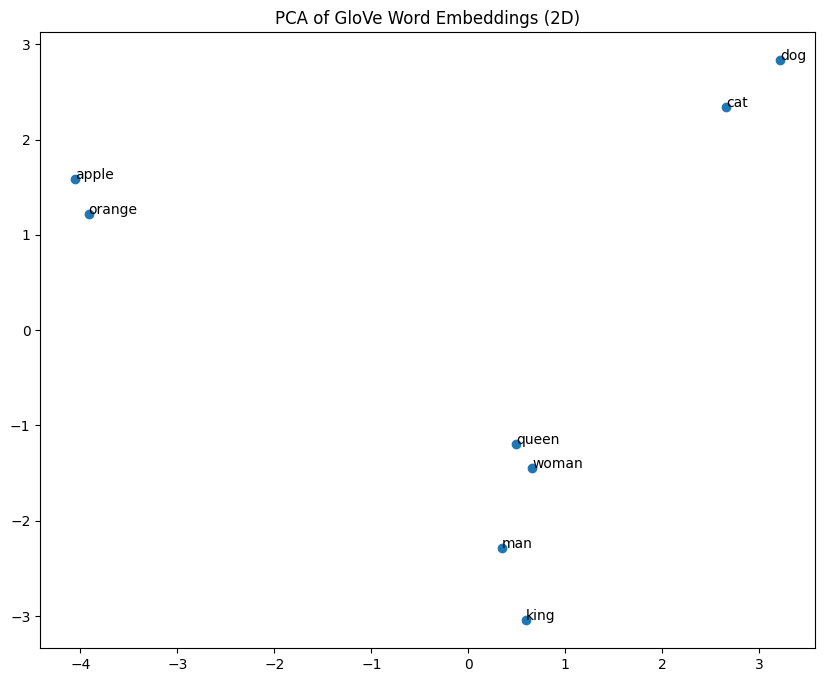

In [2]:
words_to_visualize = ["king", "queen", "man", "woman", "apple", "orange", "dog", "cat"]
visualize_embeddings_with_pca(glove_model, words_to_visualize)

### Analysis of Clustering Patterns in GloVe Word Embeddings:

#### Cluster 1: Gender-related words
- The words **"king"**, **"queen"**, **"man"**, and **"woman"** are closely clustered together.
- **"King"** and **"queen"** are particularly close, reflecting their shared semantic relationship as royal titles.
- Similarly, **"man"** and **"woman"** form a sub-cluster, showing their connection as gender-specific terms.
- This cluster highlights the GloVe model's ability to capture semantic relationships within the same category.

#### Cluster 2: Fruit-related words
- The words **"apple"** and **"orange"** are tightly grouped together, indicating their similarity as fruits.
- They form their own distinct cluster, separate from other categories, such as gender and animals.
- This distinct clustering shows that the model understands categorical differences based on co-occurrence patterns in the corpus.

#### Cluster 3: Animal-related words
- The words **"dog"** and **"cat"** are positioned near each other, reflecting their relationship as domesticated animals.
- This cluster is well-separated from the fruit and gender-related clusters, emphasizing the model's ability to distinguish between different semantic categories.

#### Overall Observations:
- The **GloVe model** has effectively learned to group words based on their semantic similarity, forming distinct clusters for gender-related terms, fruits, and animals.
- The proximity of **"king"** to **"queen"** and **"man"** to **"woman"** demonstrates the model's ability to capture analogies and shared relationships.
- The separation between clusters (e.g., gender vs. fruits vs. animals) further highlights the model's success in encoding semantic differences.

This clustering pattern validates the effectiveness of GloVe in capturing semantic relationships and differentiating between categories in the vector space.
